**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [2]:


## cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import  MinMaxScaler

air_quality_dataset = pd.read_csv("./data/AirQualityUCI.csv", sep=";", decimal=",")
#Limpio un poco el dataset

air_quality_dataset.drop(columns=["Unnamed: 15", "Unnamed: 16"], inplace=True)

air_quality_dataset.dropna(inplace=True, how="all")



In [3]:
## ¿cuántas instancias tiene el dataset?
print(f"El dataset tiene {air_quality_dataset.shape[0]} instancias con {air_quality_dataset.shape[1]} columnas")

El dataset tiene 9357 instancias con 15 columnas


El dataset tiene 9357 instancias con 15 columnas.

In [4]:
## ¿cuál es el tipo de datos de cada una de las columnas?
air_quality_dataset.info()
air_quality_dataset.head()



<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


_indica aquí tu respuesta_


| # | Column Name    | Dtype   |
|---|----------------|---------|
| 0 |  Date          | str     |
| 1 |  Time          | str     |
| 2 |  CO(GT)        | float64 |
| 3 |  PT08.S1(CO)   | float64 |
| 4 |  NMHC(GT)      | float64 |
| 5 |  C6H6(GT)      | float64 |
| 6 |  PT08.S2(NMHC) | float64 |
| 7 |  NOx(GT)       | float64 |
| 8 |  PT08.S3(NOx)  | float64 |
| 9 |  NO2(GT)       | float64 |
| 10|  PT08.S4(NO2)  | float64 |
| 11|  PT08.S5(O3)   | float64 |
| 12|  T             | float64 |
| 13|  RH            | float64 |
| 14|  AH            | float64 |

In [5]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

_indica aquí tu respuesta_

* Columnas categóricas: 2 (Date, Time)
* Columnas continuas: 14 (CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH)
* Sin embargo, es importante destacar que las columnas categóricas (Date y Time) podrían ser transformadas en variables numéricas para su uso en modelos de regresión, dependiendo del enfoque que se quiera tomar para el análisis. En mi caso haré esto.
* Adicional todas las variables PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2) y PT08.S5(O3) son consideradas categóricas dentro de la documentación del problema, sin embargo dado que estos se refieren a respuestas de los sensores, se pueden considerar como variables continuas para el análisis.

In [6]:
## ¿existen valores nulos en el dataset?
# Los valores -200 son valores vacíos
air_quality_dataset.replace(-200,np.nan, inplace=True)
air_quality_dataset.isna().sum()


Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

_indica aquí tu respuesta_

* Sí, existen valores nulos en el dataset. Recordar que los valores -200 son considerados valores faltantes por la documentación del problema. Por ahora los asigno a nan a reservas de un análisis posterior. Sin embargo hay que notar que se debe realizar un tratamiento de estos valores "ausentes" para poder usar los modelos con certeza. Para los siguientes análisis realizaré el análisis omitiendoles pero previamente a la implementación de los modelos se realizará un tratamiento de estos valores faltantes.

In [7]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
air_quality_dataset["C6H6(GT)"].info()

<class 'pandas.Series'>
RangeIndex: 9357 entries, 0 to 9356
Series name: C6H6(GT)
Non-Null Count  Dtype  
--------------  -----  
8991 non-null   float64
dtypes: float64(1)
memory usage: 73.2 KB


_indica aquí tu respuesta_
* Dado el paper original la variable de respuesta es el nivel de benceno. El problema gira alrededor de realizar el calibrado de la naríz electrónica para el benceno. Esto es comparado con los resultados de un espectrómetro de gases para poder determinar si se puede encontrar una manera de definir los niveles de benceno de manera práctica y sin recurrir a los espectrómetros. Es de tipo continua y está codificada como float64. En términos prácticos y a reservas de los valores de correlación en realidad se podría usar cualquier variable como variable respuesta. Me alineo a la problemática original y elijo el benceno como variable objetivo.

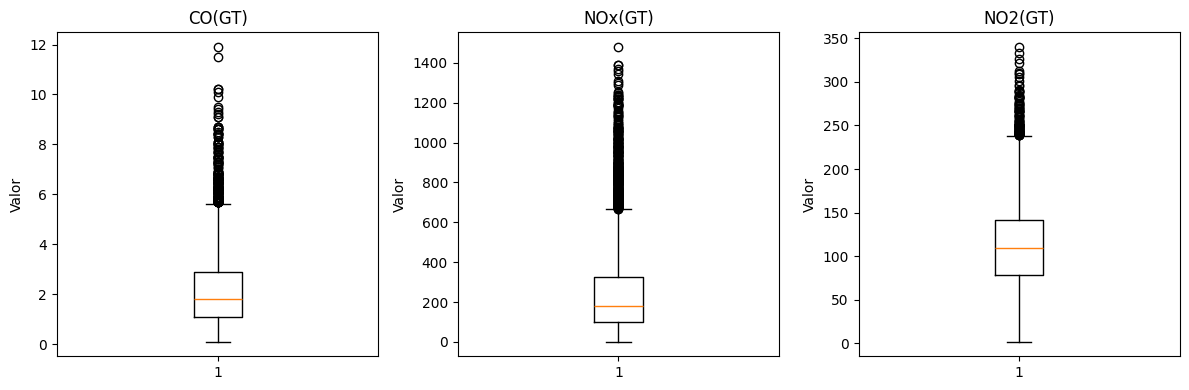

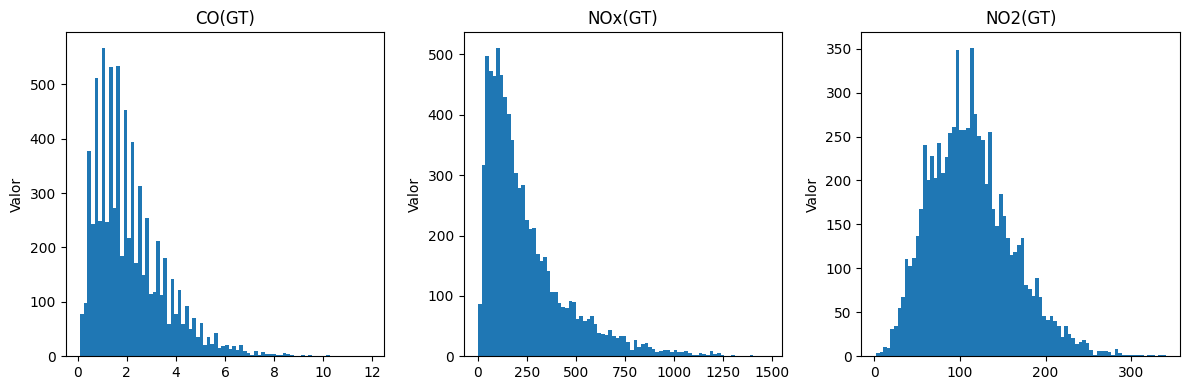

,CO(GT),NOx(GT),NO2(GT)
count,7674.000000,7718.000000,7715.000000
mean,2.152750,246.896735,113.091251
std,1.453252,212.979168,48.370108
min,0.100000,2.000000,2.000000
25%,1.100000,98.000000,78.000000
50%,1.800000,180.000000,109.000000
75%,2.900000,326.000000,142.000000
max,11.900000,1479.000000,340.000000


In [8]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
cols=["CO(GT)","NOx(GT)", "NO2(GT)"]
air_quality_dataset[cols].describe(include="all")
columnas = ["CO(GT)", "NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, columna in zip(axes, columnas):
    ax.boxplot(air_quality_dataset[columna].dropna())
    ax.set_title(columna)
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, columna in zip(axes, columnas):
    ax.hist(air_quality_dataset[columna].dropna(), bins=80)
    ax.set_title(columna)
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.show()
air_quality_dataset[cols].describe(include="all")


_indica aquí tu respuesta_

Las variables muestran una distribución con skew a la izquierda, una campana asimétrica. Lo que se confirma con una diferencia entre media y mediana prolongada a la derecha. No se trata de una distribución normal aunque resulta parecida. Podría ser una distribución chi-cuadrada. Se requeriría un análisis más profundo para poder determinar la distruibución exacta, sin embargo, para objetos ilustrativos solo menciono el skew a la izquierda.

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

_indica aquí tu respuesta_


Existen algunos outliers en las variables mencionadas. Se puede observar en los bigotes una buena cantidad de valores atícos principalmente en la parte superior. De hecho la parte inferior parece estar más concentrada en un rango más estrecho, mientras que la parte superior tiene una mayor dispersión. Esto incinua un skew hacia lña izquierda lo cual es confirmado en los histogramas. Simplemente, para confirmar los estadísticos muestran un maximo muy elevado en comparación con la media y la mediana, lo cual es un indicativo de la presencia de outliers. Cómo ya mencione para los presentes análisis se omitieron los valores faltantes, pero es importante destacar que se debe realizar un tratamiento de estos valores "ausentes" para poder usar los modelos con certeza. Para los siguientes análisis realizaré el análisis omitiendoles, pero previamente a la implementación de los modelos se realizará un tratamiento de estos valores faltantes.

<Axes: >

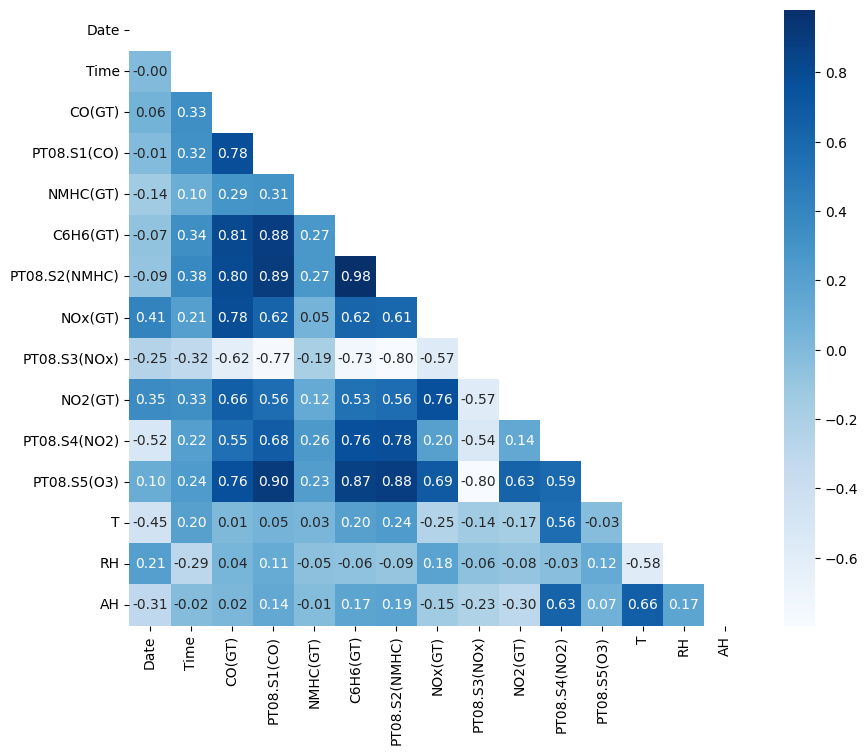

In [9]:
## ¿cómo son las correlaciones entre las variables del dataset?
import seaborn as sns
from  sklearn.impute import SimpleImputer

#Voy a linealizar la hora y sustituir la fecha por un entero.
time_stamp=pd.to_datetime(air_quality_dataset["Time"], format="%H.%M.%S")
air_quality_dataset["Time"]= time_stamp.dt.hour * 360 +time_stamp.dt.minute *60 +time_stamp.dt.second

# similar con el día
base_date=pd.to_datetime("1977-01-01")
air_quality_dataset["Date"] = (pd.to_datetime(air_quality_dataset["Date"], format="%d/%m/%Y")-base_date).dt.days

air_quality_dataset = air_quality_dataset.select_dtypes(include=["number"])

# realizo un tratamiento de faltantes usando la media.
imputer = SimpleImputer(strategy="median")
air_quality_dataset = pd.DataFrame(imputer.fit_transform(air_quality_dataset), columns=air_quality_dataset.columns, index=air_quality_dataset.index)

correlation_matrix = air_quality_dataset.corr(method="pearson")

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    square=True,
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)),
    ax=ax)


_indica aquí tu respuesta_

**Notar que en este punto ya estoy haciendo tratamiento con los valores "ausentes" para poder tener una mejor idea de las correlaciones y realizé una transformación de fecha y hora.**

Hay una fuerte correlación positiva entre el monóxido de carbono y ozono y prácticamente todas las variables químicas, la temperatura y la humedad parecen tener las relaciones más débiles a excepción de la respuesta del sensor de bióxido de nitrógeno que tiene una correlación más fuerte con la temperatura y la humedad absoluta. En general las variables químicas parecen ser buenos predictores de la variable objetivo y entre ellas.

<Axes: >

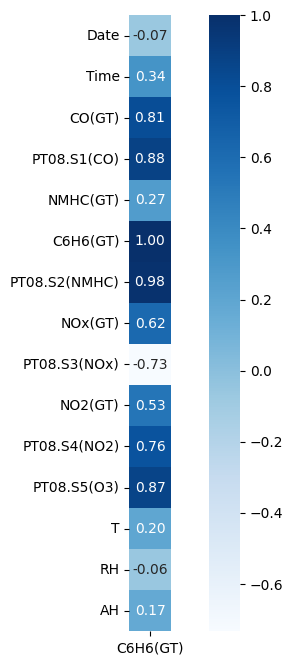

In [10]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
f, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(pd.DataFrame(correlation_matrix["C6H6(GT)"]),
    annot=True,
    fmt=".2f",
    cmap='Blues',
    square=True,
    ax=ax)

_indica aquí tu respuesta_

Las respuestas de los sensores para hidrocarburos no metánicos, monóxido de carbono y ozono son las tres variables más correlacionadas con la variable objetivo benceno con una correlación de 0.98, 0.88 y 0.87 respectivamente.


In [11]:
#Existen variables sin correlación?
zero_corr = (correlation_matrix == 0).sum().sum() - len(correlation_matrix)  # Resta la diagonal (siempre 1)
weak_corr = correlation_matrix.where(np.triu(np.ones_like(correlation_matrix), k=1).astype(bool))
weak_pairs = weak_corr.stack().reset_index()
weak_pairs.columns = ['Variable1', 'Variable2', 'Correlacion']
weak_pairs['Abs_Correlacion'] = weak_pairs['Correlacion'].abs()
weak_pairs = weak_pairs[weak_pairs['Abs_Correlacion'] < 0.1].sort_values(by='Abs_Correlacion')
print("Pares con correlación absoluta < 0.1:")
print(weak_pairs.head(20))

Pares con correlación absoluta < 0.1:
        Variable1      Variable2  Correlacion  Abs_Correlacion
1            Date           Time    -0.003249         0.003249
3            Date    PT08.S1(CO)    -0.005383         0.005383
42         CO(GT)              T     0.006049         0.006049
74       NMHC(GT)             AH    -0.012150         0.012150
29           Time             AH    -0.018431         0.018431
44         CO(GT)             AH     0.022864         0.022864
177   PT08.S5(O3)              T    -0.026814         0.026814
72       NMHC(GT)              T     0.030171         0.030171
163  PT08.S4(NO2)             RH    -0.032172         0.032172
43         CO(GT)             RH     0.041137         0.041137
73       NMHC(GT)             RH    -0.046864         0.046864
67       NMHC(GT)        NOx(GT)     0.048855         0.048855
57    PT08.S1(CO)              T     0.048985         0.048985
2            Date         CO(GT)     0.055202         0.055202
133  PT08.S3(NOx)

_indica aquí tu respuesta_

No hay una que tenga una correlación 0, pero la humedad, la humedad absoluta y la temperatura son las que tienen la correlación más débil con las demás variables. Hablando específicamente del benceno la correlación más débil se dá con la humedad relativa.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

_indica aquí tu respuesta_

Considerando el EDA podemos decir que:

* La temperatura, humedad relativa y humedad absoluta son los peores predictores para el benceno, y pueden ser candidatos a ser descartados dentro del modelo.
* El resto de las variables parecen ser buenos predictores aunque me inclino por el PT08.S1(CO), el PT08.S2(NMHC) y el PT08.S5(O3) como los mejores predictores, hora y fecha no me parecen significativas para el modelo pero aún así son mejores que las variables ambientales.
* Existen outliers y una discordancia en magnitud dentro de las variables por lo que una normalización es necesaria.
* Las variables no parecen ser lineales por lo que la regresión lineal simple no parece ser la mejor opción, aunque se puede usar como baseline.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [12]:
standar_scaler = MinMaxScaler()
air_quality_dataset_normalized = pd.DataFrame(standar_scaler.fit_transform(air_quality_dataset), columns = air_quality_dataset.columns, index=air_quality_dataset.index)
air_quality_dataset_normalized.describe()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,0.500481,0.499937,0.168585,0.324043,0.126668,0.155809,0.303099,0.157873,0.217001,0.326548,0.407162,0.347334,0.434356,0.503755,0.410327
std,0.288599,0.301008,0.112121,0.152844,0.056733,0.114965,0.142887,0.132086,0.106653,0.130025,0.152594,0.169759,0.186198,0.213521,0.193461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.251282,0.217391,0.093220,0.211055,0.120981,0.070755,0.196614,0.074475,0.145701,0.248521,0.310701,0.226325,0.298925,0.344654,0.274349
50%,0.500000,0.478261,0.144068,0.298636,0.120981,0.127358,0.287275,0.120515,0.204998,0.316568,0.410072,0.322328,0.423656,0.508176,0.396178
75%,0.751282,0.782609,0.211864,0.412060,0.120981,0.212264,0.394320,0.190928,0.270224,0.387574,0.499550,0.449175,0.559140,0.662893,0.543175
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# separar datos de entrenamiento y test
from sklearn.model_selection import train_test_split

X = air_quality_dataset_normalized.drop(columns = ['C6H6(GT)']).copy()
y = air_quality_dataset_normalized['C6H6(GT)']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)



In [14]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción
X_train_one_variable = X_train[["PT08.S2(NMHC)"]]
X_test_one_variable = X_test[["PT08.S2(NMHC)"]]

In [15]:
# entrena el modelo con los datos de entrenamiento
from sklearn import linear_model

linear_regression_one_variable = linear_model.LinearRegression()
linear_regression_one_variable.fit(X_train_one_variable, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?
print(f"El valor aprendido para el coeficiente es {linear_regression_one_variable.coef_[0]} y el valor aprendido para la constante es {linear_regression_one_variable.intercept_}")


El valor aprendido para el coeficiente es 0.7921318509194819 y el valor aprendido para la constante es -0.08407716025761275


Explica qué indican estos parámetros

_indica aquí tu respuesta_

Los parámetros indican que hay una relación fuerte entre el PT08.S2(NMHC) y el benceno. Esto es, cuando el PT08.S2(NMHC) aumenta el benceno aumenta en una proporción similar. El coeficiente indica que para un PT08.S2(NMHC) de 0 el benceno será -0.084 aproximadamente lo que manifiesta una recta que cruza casi por el centro de la intersección de los ejes. Recordar que estos montos son normalizados entre 0 y 1, lo que implica que el modelo predice un aumento de 0.98 en el benceno por cada aumento de 1 en el PT08.S2(NMHC), es decir se tendría que desnormalizar los valores para poder interpretarlos en términos físicos, pero para términos de evaluación del modelo es suficiente con esta interpretación.

In [17]:
# realiza las predicciones para el conjunto de datos de test
y_predicted = linear_regression_one_variable.predict(X_test_one_variable)

In [18]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.5f}")
print(f"MSE  (Mean Squared Error): {mse:.5f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.5f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.5f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.5f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.01562
MSE  (Mean Squared Error): 0.00044
RMSE (Root Mean Squared Error): 0.02089
R^2  (Coeficiente de Determinación): 0.96535
MAPE (Mean Absolute Percentage Error): 0.35063%


_indica aquí tu respuesta_

Hay un punto a resaltar aquí. Y es que en el análisis estadístico se descubrió una serie de outliers en los bigotes de la gráfica de caja. Igualmente, un skew en el histograma, lo cual quiere decir que en el extremo superior hay valores atípicos. Siendo así usaría MAE, ya que es más robusta para valores atípicos. Este valor es de 0.01562 lo cual es bastante bueno y R2 es de 0.96535 lo cual implica que el modelo explica gran parte de la varianza.

In [19]:
# ¿Qué error tiene el modelo? Explícalo.

_indica aquí tu respuesta_

El error total del modelo es de 0.02089, este valor está normalizado entre 0 y 1, lo que implica que el modelo tiene un error del 2.089% aproximadamente. El rendimiento del modelo se puede medir por R2 el cual es de 0.96535 lo que implica un buen rendimiento.

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [20]:
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Coeficientes:
for col, coef in zip(X_train.columns, linear_regression.coef_):
    print(f"El valor aprendido para el coeficiente de {col} es {coef}")
print(f"El valor aprendido para la constante es {linear_regression.intercept_}")

El valor aprendido para el coeficiente de Date es 0.06353296064570056
El valor aprendido para el coeficiente de Time es -0.010655690392582046
El valor aprendido para el coeficiente de CO(GT) es 0.04098516185921545
El valor aprendido para el coeficiente de PT08.S1(CO) es 0.023036575956861902
El valor aprendido para el coeficiente de NMHC(GT) es 0.0019099376900876801
El valor aprendido para el coeficiente de PT08.S2(NMHC) es 0.8043618343294917
El valor aprendido para el coeficiente de NOx(GT) es 0.008656563554930455
El valor aprendido para el coeficiente de PT08.S3(NOx) es 0.22080412467631824
El valor aprendido para el coeficiente de NO2(GT) es -0.04630805254066722
El valor aprendido para el coeficiente de PT08.S4(NO2) es 0.15434439411198658
El valor aprendido para el coeficiente de PT08.S5(O3) es -0.005695492278351201
El valor aprendido para el coeficiente de T es -0.06140211466129024
El valor aprendido para el coeficiente de RH es -0.03393648340559551
El valor aprendido para el coefici

In [22]:
y_predicted = linear_regression.predict(X_test)
# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.3f}")
print(f"MSE  (Mean Squared Error): {mse:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.3f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.3f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.010
MSE  (Mean Squared Error): 0.000
RMSE (Root Mean Squared Error): 0.015
R^2  (Coeficiente de Determinación): 0.983
MAPE (Mean Absolute Percentage Error): 0.158%


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

_indica aquí tu respuesta_

El valor del error es de 0.015 lo que implica un valor de 1.5% aproximadamente, es ligeramente mejor que el anterior, aunque el cambio no es significativo. El R2 también mejoró ligeramente a 0.983. Considero que es necesario un análisis usando VIF y ANOVA para determinar si hay multicolinealidad entre las variables, lo cual podría explicar la mejora tan leve a pesar de usar más variables. De hecho hice un experimento, no lo muestro aquí, pero eliminé algunas variables y el rendimiento mejoró a 0.99. Dejo el análisis original, pues me parece ilustrativo, pero me queda claro que la perdida de parsimonia en el modelo puede ser un factor para el rendimiento del mismo. Como mencioné antes es mejor un análisis para verificar la ortogonalidad de las variables y aumentar la parsimonia del modelo.

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

_indica aquí tu respuesta_

* Criterion: Indica cuál es el algorítmo/función que se va a usar para medir la calidad de una partición. Se puede usar el error cuadrático medio, por ejmeplo. En este caso se usa poisson, el cual usa la reduccción de la desviación de la media de Poisson para determinar la calidad de las particiones.

* Splittter: Indica cuál estrategia se usara para elegir una partición, podría ser "best" para elegir la mejor o "random" para elegir una aleatoria entre las mejores.

* max_depth: Indica un método para detener la construcción del árbol, el árbol no puede crecer más allá de max_depth. Si fuera None entonces el árbol crece hasta que solo exista una sola clase en las hojas o que contenga menos de min_samples_split muestras.
* min_samples_split: Indica el número mínimo de muestras para realizar la divisón, si existen menos de min_samples_split muestras entonces no se realiza la división y se considera una hoja.

* min_samples_leaf: Indica el número mínimo de muestras que debe contener una hoja. Si la hoja tiene menos de min_samples_leaf entonces esa hoja se elimina.

* max_features: Indica el número de predictores a usarse en una partición, None indica usar todos los predictores.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

_indica aquí tu respuesta_

min_impurity_decrese: Indica que un nodo se dividirá si la reducción de la impureza es mayor o igual a este valor. Esto ayuda a simplificar el módelo reduciendo divisiones que no aportan de manera significativa a la eficiencia general del árbol.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [23]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_split=10, min_samples_leaf=2,random_state=0, max_features=None)
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'poisson'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_node

Calcula MAE, R2 y RMSLE

In [24]:
y_predicted = tree.predict(X_test)
# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.5f}")
print(f"MSE  (Mean Squared Error): {mse:.5f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.5f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.5f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.5f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.00024
MSE  (Mean Squared Error): 0.00000
RMSE (Root Mean Squared Error): 0.00122
R^2  (Coeficiente de Determinación): 0.99988
MAPE (Mean Absolute Percentage Error): 0.00192%


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

In [26]:
y_predicted_train = tree.predict(X_train)
# Calcular métricas
mae = mean_absolute_error(y_train, y_predicted_train)
mse = mean_squared_error(y_train, y_predicted_train)
rmse = root_mean_squared_error(y_train, y_predicted_train)
r2 = r2_score(y_train, y_predicted_train)
mape = mean_absolute_percentage_error(y_train, y_predicted_train)

####
# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.5f}")
print(f"MSE  (Mean Squared Error): {mse:.5f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.5f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.5f}")


Evaluación del modelo:
MAE  (Mean Absolute Error): 0.00019
MSE  (Mean Squared Error): 0.00000
RMSE (Root Mean Squared Error): 0.00190
R^2  (Coeficiente de Determinación): 0.99973


_Respuesta_

El modelo para el conjunto de entrenamiento tiene un MSE de 0.00000 contra un MSE de 0.00000 de la predicción con el conjunto de prueba y los R2 son similares 0.00019 contra 0.00024, lo que implica que no hay overfitting.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

_indica aquí tu respuesta_

En el análisis de regresión lineal se comentó que se debería de hacer un análisis VIF para retirar predictores con correlación entre sí. Omitiendo dicho análisis y solo con lo visto en este experimento el módelo de árboles parece tener un rendimiento ligeramente mejor que el modelo de regresión. Pero, el modelo de regresión tiene mayor parsimonia y definitivamente es más interpretable. No creo que la complejidad del modelo de árboles justifique la mejora leve en rendimiento. En términos prácticos me parece que ambos modelos tienen un rendimiento similar pero si el objetivo es interpretabilidad eligiría regresión.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

_Respuesta_

En terminos de error y R2 el árbol obtuvo el mejor rendimiento. Hay algunos puntos a destacar, insisto en un análisis VIF para reducir la complejidad de todos los módelos, a excepción del modelo de regresión con una variable. Considero que muchas de las variables tienen correlación entre ellas y, por lo tanto, no son ortogonales. En términos de interpretabilidad regresión siempre será más interpretable, sobre todo considerando los parámetros usados en el árbol, los cuales añaden cierta complejidad al modelo. Leí que sklearn usa descomposición de valores singulares lo que la hace precisa por lo que en términos computacionales el entrenamiento resulta similarmente complejo. Estoy usando un equipo con procesador i7 de 12a generación con 64 GB en RAM, actualmente no estoy usando librerías compiladas para CUDA 13, pero aun así no note diferencias en los tiempos de entrenamiento. No considero que sea un factor relevante desde el punto de vista subjetivo en este caso.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

---

_introduce aquí la referencia APA del artículo_

Gwilliam, B. (2022). Using 2021 Field Data to Model Change in Forest Inventory Attributes From a 2014 LiDAR Derived Inventory for the United Counties of Prescott and Russell, Ontario [Tesis de Maestría, University of Toronto]. TSpace Repository. handle.net

https://utoronto.scholaris.ca/items/c7920be9-d8bc-4547-9837-f34fca403bf5

---

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.


El articulo detalla el análisis de modelos para predecir el cambio en datos de campo para el inventario forestal incluyendo el área basal, altura de los árboles y volumen. Se realiza una introducción de los dos modelos a usar, regresión por medio regresión polinomial y árboles de decisión dando a entender sus particularidades y mencionando artículos adicionales que comparan ambos modelos en otros campos.


El problema se enfoca en la importancia que tiene el inventariado forestal como un proceso ecológico afectado por factores antropogénicos. Se desea hacer una comparación de ambos modelos para predecir cambios en el área basal, volumen y altura desde 2014 hasta 2021 y determinar qué modelo aplicar.


Se realiza un muestreo en un área de 200 kilómetros cuadrados cuadrados con una población de 89000 habitantes a 50 kilómetros de Ottawa.
Se usa una técnica llamada LiDAR (Airborne Laser Scanning) que se realiza por medio de aeronaves que contienen un láser dirigido, instrumentos GPS y un giroscopio lo que permite hacer un escaneo topográfica de áreas boscosas.


Se realiza una calibración usando celdas de 200 metros cuadrados y se usaron algoritmos específicos para el inventario forestal para determinar la línea base. Luego se uso el LiDAR sondeando la zona y usando el software especializado LiDAR para obtener los predictores, usando estos datos se usó un modelo de regresión polinomial y árboles de decisión para su comparación.
Existe ya un inventario de 2014 que se uso dentro del cálculo restando este monto a los cálculos realizados según se describe en el párrafo anterior y dividiendo entre 7.
Los modelos se entrenaron usando R y RStudio y las métricas a comparar fueron R2 y RMSE.


Los datos obtenidos para regresión fueron para el área basal R2 = 0.52, y RMSE 3.42, volumen R2=0.35 y RMSE 63.74, altura R2=0.76 y RMSE 1.89; para árboles de decisión para área basal R2=0.64 y RMSE 3.12, para volumen R2=0.4 y RMSE = 58.54 y finalmente para altura R2=0.20 y RMSE 1.77.


Hay algo a destacar en las conclusiones y es que, aunque los árboles de decisión en general tuvieron un mejor desempeño ellos tuvieron una varianza más alta, prediciendo valores extremos para aquellos valores fuera de los rangos en los datos de entrenamiento. El estudio hace hincapié en que hay estudios donde, en general, los árboles aleatorios tienden a ser mejores predictores, pero esto podría deberse a la cantidad de muestras usadas. En este casi en especial la cantidad de muestras fue limitado.


Se optó entonces por elegir un modelo de regresión cuadrática que no muestra las limitaciones de los árboles de decisión en el sentido mencionado.

_Declaración de uso de IA_

Se realizó el análisis principalmente teniendo como base el laboratorio realizado anteriormente, el código fue escrito principalmente con base en él. Sin embargo, usé la inteligencia artificial de Idea para resolver dudas puntuales sobre el uso de funciones principalmente de graficación. respuestas escritas fueron realizadas por mí.

El autocompletado de código tuvo que ser deshabilitado en ocasiones para evitar código boilerplate y en ocasiones resultó ser invasivo.

Sin embargo, con tareas repetitivas el autocompletado asistido resolvió mucho del trabajo de tecleado.

Se realizó el análisis usando Pycharm con licencia pagada con GitHub copilot desactivado pero usando AI Assistant de Idea con un LLM OpenAI.